#### <p style='text-align: justify;'>1. Парциальные давления паров компонентов идеального раствора двух жидкостей (бинарного раствора) согласно [закону Рауля](https://ru.wikipedia.org/wiki/%D0%97%D0%B0%D0%BA%D0%BE%D0%BD%D1%8B_%D0%A0%D0%B0%D1%83%D0%BB%D1%8F) связаны с составом раствора соотношениями: $p_1 = x_1p^*_1$ и $p_2 =x_2p^*_2$, где $p^*_i$ — давление пара над чистой жидкостью $i$, а $x_i$ — мольные доли компонентов в жидкости. Для бинарной смеси $x_1 +x_2 =1$. Таким образом, полное давление пара над жидкостью: $$p=p_1+p_2=x_1p^*_1+x_2p^*_2= x_1p^*_1+(1-x_1)p^*_2 \: \mathrm{,}$$ а мольные доли компонентов в паре: $$y_1 = \frac{p_1}p = \frac{x_1p^*_1}{x_1p^*_1+(1-x_1)p^*_2} \: \mathrm{и} \: y_2 = \frac{p_2}p = \frac{x_2p^*_2}{x_1p^*_1+(1-x_1)p^*_2}\: \mathrm{.}$$<br>Для этанола $p^*_1=44.5 \: \mathrm{mmHg}$, для воды $p^*_2=23.8 \: \mathrm{mmHg}$ (всё при $298 \: \mathrm K$). Предполагая, что раствор этанола в воде подчиняется уравнениям для идеального раствора, постройте график зависимости мольной доли этанола в паре ($y_1$) от мольной доли этанола в растворе ($x_1$) при $298 \: \mathrm K$. Для наглядности, дополнительно проведите прямую $y=x$, соответствующую составу раствора.

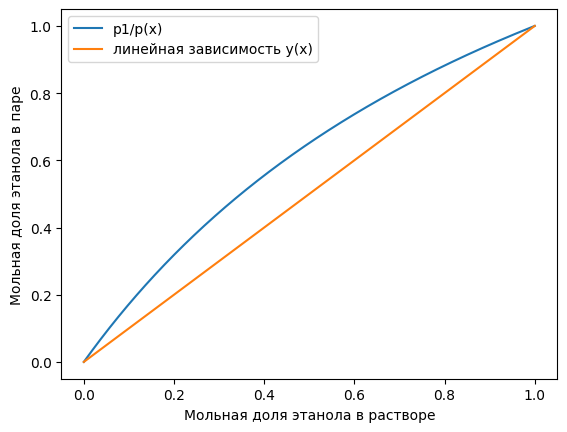

In [12]:
import numpy as np
import matplotlib.pyplot as plt
x1=0
p1_pure = 44.5
p2_pure = 23.8
p = p1_pure*x1 + (1-x1)*p2_pure
y1 = (p1_pure*x1)/p

x1 = np.linspace(0,1,600)
y1 = (p1_pure*x1)/((x1*p1_pure)+(1-x1)*p2_pure)
plt.Figure()
plt.plot(x1, y1, label='p1/p(x)')
plt.plot(x1, x1, label='линейная зависимость y(x)')
plt.legend()
plt.xlabel('Мольная доля этанола в растворе')
plt.ylabel('Мольная доля этанола в паре')
plt.show()

#### <p style='text-align: justify;'> 2. Экспериментальные значения давления пара для растворов этанол-вода разного состава приведён в файле `share/ethanol-water-vle-mass.txt`. Эти данные содержат массовые доли этанола $w_1$ в растворе и в паре, выраженные в процентах. Для пересчёта этих значений в мольные доли используйте соотношение: $$x_1 = \frac{w_1/M_1}{w_1/M_1 +(100-w_1)/M_2} \: \mathrm{,}$$ где $M_1$ и $M_2$ — молярные массы этанола и воды соответственно. Добавьте к графику, построенному в задании 1, экспериментальные данные и сделайте вывод, является ли раствор идеальным.

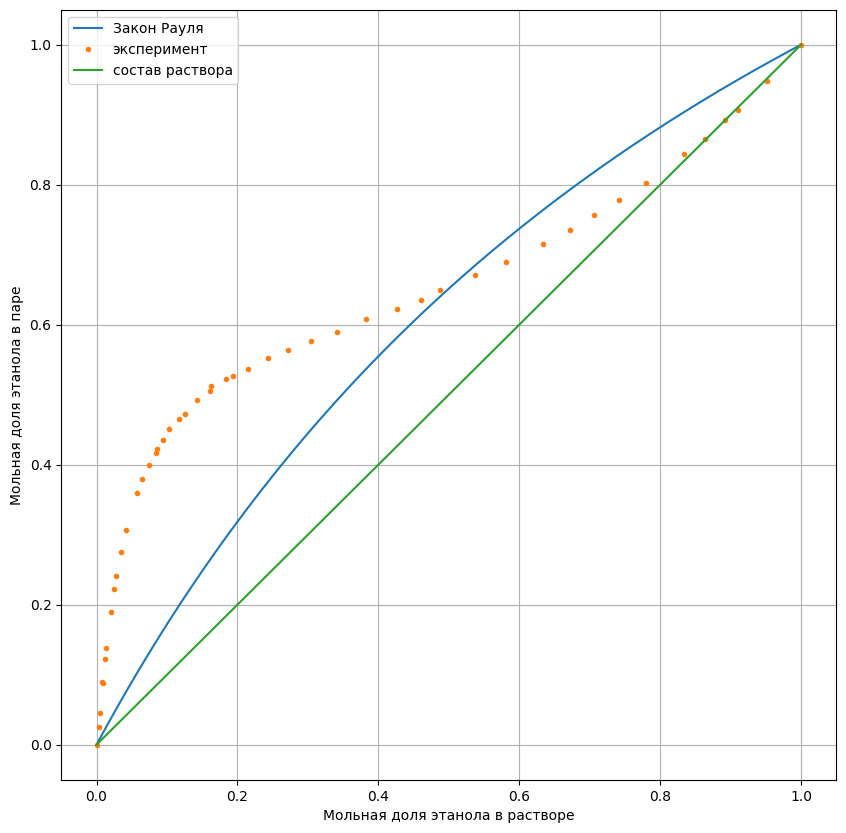

In [48]:
import numpy as np
import matplotlib.pyplot as plt
x1=0
p1_pure = 44.5
p2_pure = 23.8
p = p1_pure*x1 + (1-x1)*p2_pure
y1 = (p1_pure*x1)/p

x_Et = np.loadtxt('../share/ethanol-water-vle-mass.txt', skiprows=4, usecols=0)
y_Et = np.loadtxt('../share/ethanol-water-vle-mass.txt', skiprows=4, usecols=1)
x_Et1 = (x_Et/46)/(x_Et/46+(100-x_Et)/18)
y_Et1 = (y_Et/46)/(y_Et/46+(100-y_Et)/18)


x1 = np.linspace(0,1,600)
y1 = (p1_pure*x1)/((x1*p1_pure)+(1-x1)*p2_pure)
plt.figure(figsize=[10,10])
plt.grid()
plt.plot(x1, y1, label='Закон Рауля')
plt.plot(x_Et1, y_Et1, label='эксперимент', ls=' ', marker = 'o', ms='3')
plt.plot(x1, x1, label='состав раствора')
plt.legend()
plt.xlabel('Мольная доля этанола в растворе')
plt.ylabel('Мольная доля этанола в паре')
plt.show()

#### <p style='text-align: justify;'> 3. Аппроксимируйте экспериментальные данные из задания 2 функцией следующего вида: $$y(x)= x + a(\sqrt[3]x-x) + b(\sqrt x-x) + c(x^2-x) + d(x^3-x) + e(x^4-x)$$ Добавьте на график аппроксимирующую функцию. Напечатайте полученное выражение для $y(x)$.

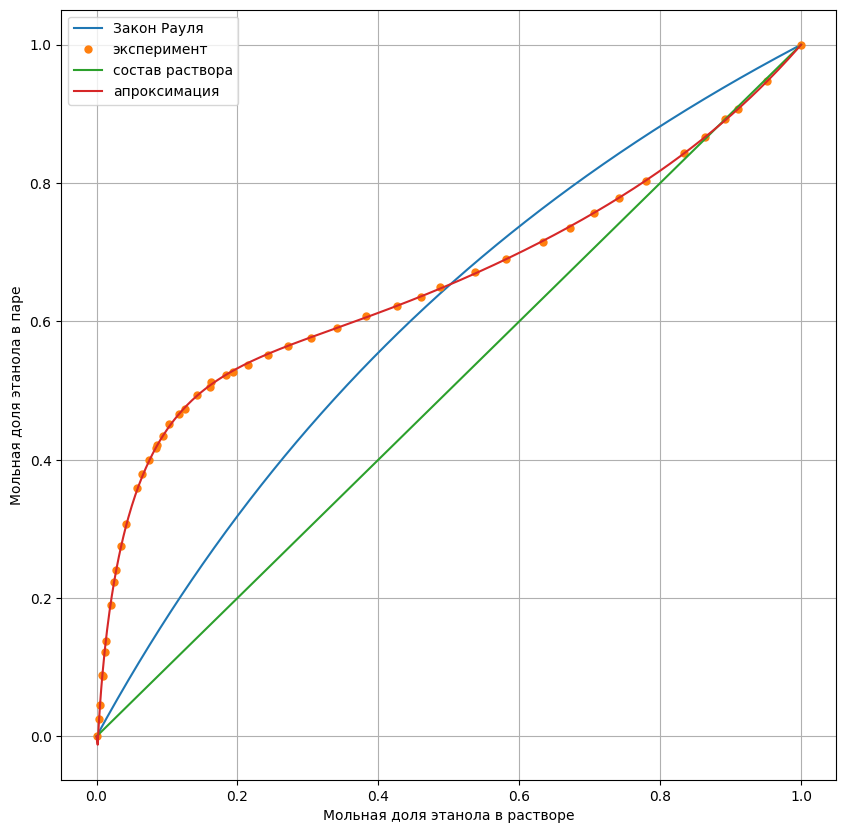

-2.34251511016891*x**(1/3) + 6.78134303440783*sqrt(x) + 1.49612375487546*x**4 - 4.25165159377958*x**3 + 6.01432390556649*x**2 - 6.69762399090129*x

In [12]:
import scipy.optimize as opt
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math

p1_pure = 44.5
p2_pure = 23.8
p = p1_pure*x1 + (1-x1)*p2_pure
y1 = (p1_pure*x1)/p
x_Et = np.loadtxt('../share/ethanol-water-vle-mass.txt', skiprows=4, usecols=0)
y_Et = np.loadtxt('../share/ethanol-water-vle-mass.txt', skiprows=4, usecols=1)
x_Et1 = (x_Et/46)/(x_Et/46+(100-x_Et)/18)
y_Et1 = (y_Et/46)/(y_Et/46+(100-y_Et)/18)

x = sym.Symbol('x')

def f(x, a, b, c, d, e):
    return x + a*(np.cbrt(x)-x) + b*(np.sqrt(x)-x) + c*(x**2-x) + d*(x**3-x) + e*(x**4-x)

guess = [1, 1, 1, 1, 1]
par, cov = opt.curve_fit(f, x_Et1, y_Et1, guess)

x1 = np.linspace(0,1,600)
y1 = (p1_pure*x1)/((x1*p1_pure)+(1-x1)*p2_pure)
plt.figure(figsize=[10,10])
plt.grid()
plt.plot(x1, y1, label='Закон Рауля')
plt.plot(x_Et1, y_Et1, label='эксперимент', ls=' ', marker = 'o', ms='5')
plt.plot(x1, x1, label='состав раствора')
plt.plot(x1, f(x1,*par), label='апроксимация' )
plt.legend()
plt.xlabel('Мольная доля этанола в растворе')
plt.ylabel('Мольная доля этанола в паре')
plt.show()
function = x + par[0]*(x**sym.Rational(1, 3) -x) + par[1]*(x**sym.Rational(1, 2)-x) + par[2]*(x**2-x) + par[3]*(x**3-x) + par[4]*(x**4-x)
display (function)

#### <p style='text-align: justify;'>4. Используя найденное в задании 3 аппроксимирующее выражение, найдите состав азеотропа (раствора, состав которого совпадает с составом пара над ним). Для численного решения уравнения используйте функцию `sympy.nsolve(F, x0)`, где `F` — выражение sympy, задающее левую часть уравнения $F(x) = 0$, `x0` — начальное приближение (функция численно найдёт только один корень, ближайший к начальному приближению).

In [13]:
sym.nsolve(function-x, 0.5)

0.880607986999464